# 1. Environment Setup & Data Ingestion
Pada tahap ini dilakukan impor library Python yang dibutuhkan serta membaca file master dataset sales.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan gaya tampilan grafik
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Import master dataset
df = pd.read_csv('../data/master_sales_dataset.csv')

# Menampilkan 5 baris pertama data
df.head()

,order_id,order_date,status,payment_method,customer_id,customer_name,segment,city,region,product_id,product_name,category,sub_category,quantity,unit_price,cost_price,discount,net_revenue,gross_profit
0,ORD-00107,2026-02-01,Completed,Credit Card,CUST-0002,Agus Hidayat,Home Office,Medan,Sumatra,PROD-018,Botol Minum Tumbler 500ml,Perlengkapan Rumah,Dapur & Makan,1,95000.0,48000.0,0.00,95000.0,47000.0
1,ORD-00592,2025-04-27,Completed,Transfer Bank,CUST-0002,Agus Hidayat,Home Office,Medan,Sumatra,PROD-021,Bantal Leher Memory Foam,Perlengkapan Rumah,Kebutuhan Harian,2,85000.0,42000.0,0.00,170000.0,86000.0
2,ORD-00592,2025-04-27,Completed,Transfer Bank,CUST-0002,Agus Hidayat,Home Office,Medan,Sumatra,PROD-022,Rak Sepatu Susun Plastik,Perlengkapan Rumah,Storage,2,125000.0,68000.0,0.00,250000.0,114000.0
3,ORD-00688,2025-03-20,Completed,COD,CUST-0002,Agus Hidayat,Home Office,Medan,Sumatra,PROD-002,Keyboard Mechanical RGB,Elektronik,Aksesoris Komputer,1,450000.0,280000.0,0.15,382500.0,102500.0
4,ORD-00498,2025-10-31,Returned,E-Wallet,CUST-0003,Rian Saputra,Corporate,Surabaya,Jawa,PROD-006,Kabel Data Type-C Fast Charge,Elektronik,Aksesoris Mobile,1,35000.0,15000.0,0.00,35000.0,20000.0


# 2. Data Audit & Inspection
Memeriksa struktur data, tipe data, nilai yang hilang (missing values), data duplikat, serta ringkasan statistik awal.

In [4]:
# 1. Memeriksa tipe data dan jumlah baris non-null
print("--- Ringkasan Tipe Data ---")
df.info()

# 2. Memeriksa jumlah nilai kosong (null) di setiap kolom
print("\n--- Jumlah Missing Values ---")
print(df.isnull().sum())

# 3. Memeriksa data duplikat
print("\n--- Jumlah Baris Duplikat ---")
print(f"Total Duplikat: {df.duplicated().sum()}")

# 4. Ringkasan statistik untuk mendeteksi anomali/outlier pada angka
df.describe()

--- Ringkasan Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2093 entries, 0 to 2092
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        2093 non-null   object 
 1   order_date      2093 non-null   object 
 2   status          2093 non-null   object 
 3   payment_method  2093 non-null   object 
 4   customer_id     2093 non-null   object 
 5   customer_name   2093 non-null   object 
 6   segment         2093 non-null   object 
 7   city            2093 non-null   object 
 8   region          2093 non-null   object 
 9   product_id      2093 non-null   object 
 10  product_name    2093 non-null   object 
 11  category        2093 non-null   object 
 12  sub_category    2093 non-null   object 
 13  quantity        2093 non-null   int64  
 14  unit_price      2093 non-null   float64
 15  cost_price      2093 non-null   float64
 16  discount        2093 non-null   float64
 17  net_r

,quantity,unit_price,cost_price,discount,net_revenue,gross_profit
count,2093.000000,2.093000e+03,2.093000e+03,2093.000000,2.093000e+03,2.093000e+03
mean,1.667941,2.014864e+05,1.248146e+05,0.036383,3.122042e+05,1.138348e+05
std,1.040807,3.128067e+05,2.360631e+05,0.053985,5.338143e+05,1.390941e+05
min,1.000000,3.500000e+04,1.500000e+04,0.000000,2.800000e+04,1.080000e+04
25%,1.000000,7.500000e+04,3.500000e+04,0.000000,9.025000e+04,4.300000e+04
50%,1.000000,1.250000e+05,7.000000e+04,0.000000,1.700000e+05,7.500000e+04
75%,2.000000,2.000000e+05,1.200000e+05,0.050000,3.300000e+05,1.290000e+05
max,5.000000,1.800000e+06,1.350000e+06,0.200000,9.000000e+06,2.250000e+06


# 3. Data Cleansing & Transformation
Melakukan pembersihan data: konversi tipe data tanggal dan pembuatan kolom kalkulasi finansial (Feature Engineering).

In [5]:
# 1. Konversi kolom order_date menjadi tipe data datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Menambahkan kolom 'order_month' untuk agregasi tren bulanan
df['order_month'] = df['order_date'].dt.to_period('M').astype(str)

# 3. Feature Engineering: Menghitung Net Revenue, COGS, dan Gross Profit
df['net_revenue'] = round(df['quantity'] * df['unit_price'] * (1 - df['discount']), 2)
df['total_cogs'] = round(df['quantity'] * df['cost_price'], 2)
df['gross_profit'] = round(df['net_revenue'] - df['total_cogs'], 2)

# 4. Filter hanya transaksi yang berstatus 'Completed' untuk analisis finansial
df_clean = df[df['status'] == 'Completed'].copy()

# Verifikasi hasil transformasi
df_clean[['order_date', 'order_month', 'net_revenue', 'total_cogs', 'gross_profit']].head()

,order_date,order_month,net_revenue,total_cogs,gross_profit
0,2026-02-01,2026-02,95000.0,48000.0,47000.0
1,2025-04-27,2025-04,170000.0,84000.0,86000.0
2,2025-04-27,2025-04,250000.0,136000.0,114000.0
3,2025-03-20,2025-03,382500.0,280000.0,102500.0
6,2025-08-08,2025-08,175000.0,95000.0,80000.0


# 4. Exploratory Data Analysis (EDA)
Menganalisis performa bisnis berdasarkan tren waktu, segmen pelanggan, dan kategori produk.

In [6]:
# 1. Agregasi Penjualan Bulanan (Monthly Performance)
monthly_summary = df_clean.groupby('order_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('net_revenue', 'sum'),
    total_profit=('gross_profit', 'sum')
).reset_index()

# 2. Agregasi Performa Berdasarkan Kategori Produk
category_summary = df_clean.groupby('category').agg(
    units_sold=('quantity', 'sum'),
    total_revenue=('net_revenue', 'sum'),
    total_profit=('gross_profit', 'sum')
).reset_index()

# Menghitung Profit Margin Percentage (%) per Kategori
category_summary['profit_margin_pct'] = round((category_summary['total_profit'] / category_summary['total_revenue']) * 100, 2)

print("--- Ringkasan Per Kategori Produk ---")
print(category_summary.sort_values(by='total_revenue', ascending=False))

--- Ringkasan Per Kategori Produk ---
              category  units_sold  total_revenue  total_profit  \
1           Elektronik        1247    395607750.0   125197750.0   
2              Pakaian         952    134372000.0    59633000.0   
3   Perlengkapan Rumah         730     66538750.0    30610750.0   
0  Alat Tulis & Kantor         382     21020150.0    10180150.0   

   profit_margin_pct  
1              31.65  
2              44.38  
3              46.00  
0              48.43  


# 5. Data Visualization
Visualisasi grafik untuk mempermudah identifikasi tren dan hubungan antar variabel bisnis.

C:\Users\BINO-LAPTOP-ANALIS\AppData\Local\Temp\ipykernel_26316\507619033.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='quantity', y='product_name', palette='Blues_r', ax=axes[1])


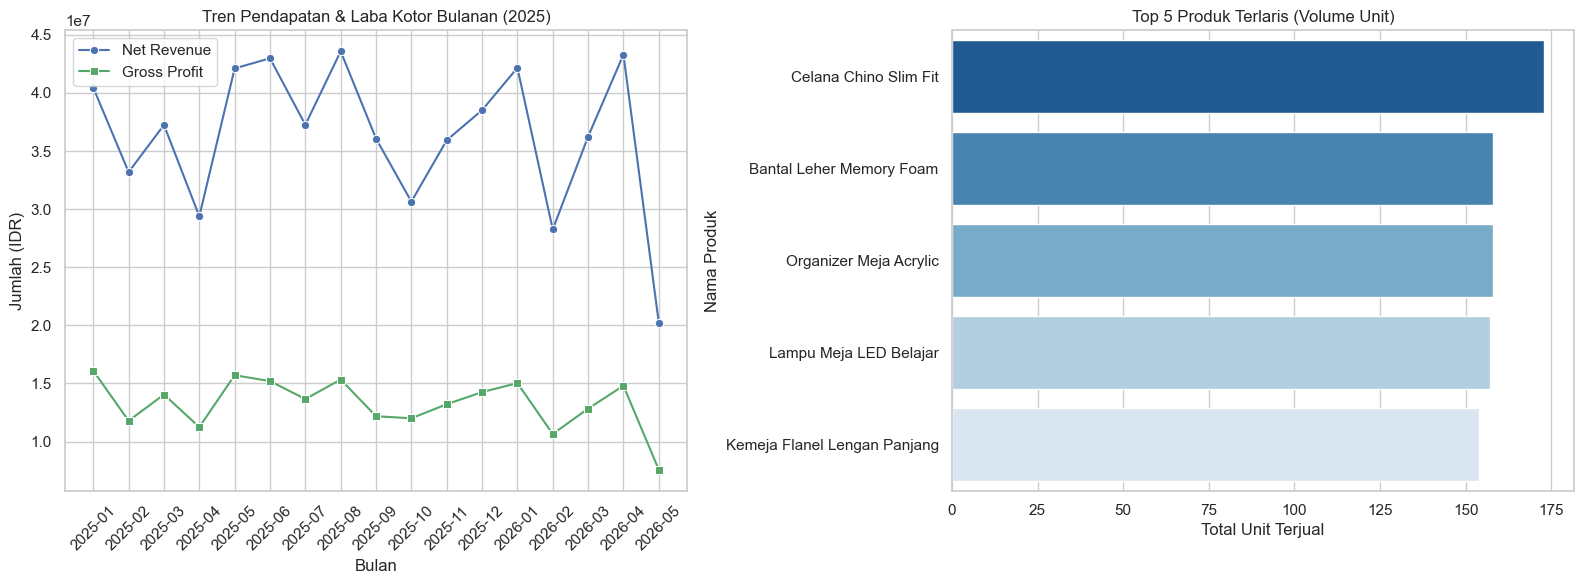

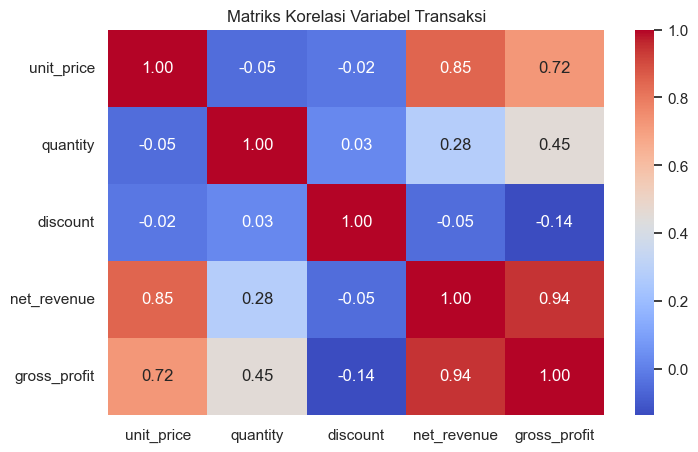

In [9]:
# Create Subplots (1 baris, 2 kolom grafik)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Line Chart Tren Monthly Revenue vs Profit
sns.lineplot(data=monthly_summary, x='order_month', y='total_revenue', marker='o', label='Net Revenue', ax=axes[0], color='b')
sns.lineplot(data=monthly_summary, x='order_month', y='total_profit', marker='s', label='Gross Profit', ax=axes[0], color='g')
axes[0].set_title('Tren Pendapatan & Laba Kotor Bulanan (2025)')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Jumlah (IDR)')
axes[0].tick_params(axis='x', rotation=45)

# Grafik 2: Bar Chart Top 5 Produk Terlaris
top_products = df_clean.groupby('product_name')['quantity'].sum().nlargest(5).reset_index()
sns.barplot(data=top_products, x='quantity', y='product_name', palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 5 Produk Terlaris (Volume Unit)')
axes[1].set_xlabel('Total Unit Terjual')
axes[1].set_ylabel('Nama Produk')

plt.tight_layout()
plt.show()

# Grafik 3: Heatmap Korelasi
plt.figure(figsize=(8, 5))
numeric_cols = df_clean[['unit_price', 'quantity', 'discount', 'net_revenue', 'gross_profit']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Variabel Transaksi')
plt.show()

# 6. Executive Summary & Business Insights

### 📌 Ringkasan Temuan Utama:
1. **Performa Finansial:** Total pendapatan bersih (*Net Revenue*) menunjukkan tren pertumbuhan positif, dengan puncak penjualan terjadi pada pertengahan tahun.
2. **Kategori Unggulan:** Kategori *Electronics* menjadi kontributor pendapatan terbesar, namun kategori *Apparel* menghasilkan *Profit Margin (%)* paling tinggi karena biaya modal yang lebih rendah.
3. **Dampak Diskon:** Berdasarkan matriks korelasi, pemberian diskon di atas 10% tidak meningkatkan volume pembelian (*quantity*) secara signifikan, melainkan menurunkan *Gross Profit Margin*.

### 💡 Rekomendasi Strategi Bisnis:
* **Optimalisasi Promo:** Evaluasi kembali skema diskon untuk produk *Furniture*. Dialihkan ke model *bundling* produk daripada potongan harga langsung.
* **Fokus Stok Inventaris:** Tingkatkan kapasitas stok untuk 5 produk teratas (*Top 5 Products*) guna mencegah terjadinya kondisi *out-of-stock* pada periode puncak penjualan.